# Phase 1 — Load, Explore & Clean
**ML Foundations Capstone | Ames Housing Dataset**

**Khaled Waleed Althobaiti | خالد وليد الثبيتي**
Class 1/1 | صف 1/1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RAW_PATH    = '../data/raw/AmesHousing.csv'
CLEAN_PATH  = '../data/cleaned/AmesHousing_clean.csv'

## 1. Load the Data

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 2. Shape & Info

In [3]:
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")
df_raw.info(verbose=True, show_counts=True)

Rows: 2,930  |  Columns: 82
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null  

## 3. Missing Values

In [4]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.to_string())

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1


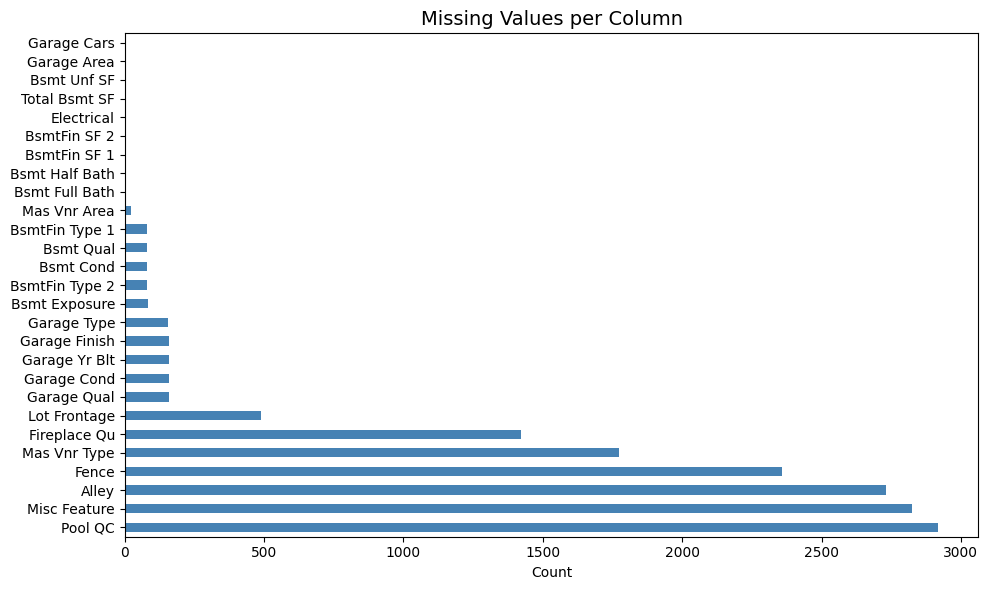

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
missing.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Missing Values per Column', fontsize=14)
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('../data/cleaned/missing_values.png', dpi=150)
plt.show()

**How I handled missing values:**

| Column group | Strategy | Reason |
|---|---|---|
| Pool QC, Misc Feature, Alley, Fence, Fireplace Qu | Fill `'None'` | Most homes don't have these — NaN means absent, not unknown |
| Garage cols (Type/Finish/Qual/Cond) | Fill `'None'` / 0 | No garage in the house |
| Basement cols | Fill `'None'` / 0 | No basement in the house |
| Lot Frontage | Median per Neighborhood | Lot sizes tend to be similar within a neighbourhood |
| Mas Vnr Type / Area | Fill `'None'` / 0 | No masonry veneer |
| Electrical | Mode | Only 1 missing row, mode is fine here |


## 4. Data Type Fixes

In [6]:
categorical_ints = ['MS SubClass', 'Mo Sold', 'Yr Sold']
for col in categorical_ints:
    df_raw[col] = df_raw[col].astype(str)
print("Converted to string:", categorical_ints)

Converted to string: ['MS SubClass', 'Mo Sold', 'Yr Sold']


## 5. Duplicates

In [7]:
dupes = df_raw.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df_raw = df_raw.drop_duplicates()
    print(f"After drop — shape: {df_raw.shape}")

Duplicate rows: 0


## 6. Outlier Detection & Capping

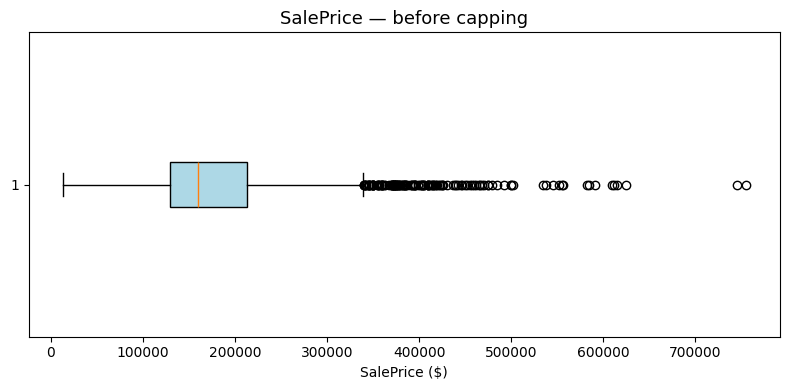

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(df_raw['SalePrice'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title('SalePrice — before capping', fontsize=13)
ax.set_xlabel('SalePrice ($)')
plt.tight_layout()
plt.savefig('../data/cleaned/saleprice_boxplot_before.png', dpi=150)
plt.show()

In [9]:
p99 = df_raw['SalePrice'].quantile(0.99)
print(f"99th percentile of SalePrice: ${p99:,.0f}")
df_raw['SalePrice'] = df_raw['SalePrice'].clip(upper=p99)

Q1 = df_raw['Gr Liv Area'].quantile(0.25)
Q3 = df_raw['Gr Liv Area'].quantile(0.75)
IQR = Q3 - Q1
upper_iqr = Q3 + 3 * IQR
n_out = (df_raw['Gr Liv Area'] > upper_iqr).sum()
print(f"Gr Liv Area — IQR upper fence: {upper_iqr:.0f} | rows above fence: {n_out}")
df_raw['Gr Liv Area'] = df_raw['Gr Liv Area'].clip(upper=upper_iqr)

99th percentile of SalePrice: $456,666
Gr Liv Area — IQR upper fence: 3593 | rows above fence: 9


## 7. `clean_data()` Function

In [10]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes the raw Ames Housing DataFrame and returns a clean version.
    All steps are in one place so I can reuse this in the other notebooks.
    """
    df = df.copy()

    categorical_ints = ['MS SubClass', 'Mo Sold', 'Yr Sold']
    for col in categorical_ints:
        df[col] = df[col].astype(str)

    df = df.drop_duplicates()

    none_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence',
                 'Fireplace Qu', 'Garage Type', 'Garage Finish',
                 'Garage Qual', 'Garage Cond',
                 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
                 'BsmtFin Type 1', 'BsmtFin Type 2', 'Mas Vnr Type']
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')

    zero_cols = ['Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
                 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath',
                 'Bsmt Half Bath', 'Garage Cars', 'Garage Area',
                 'Garage Yr Blt']
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage']                            .transform(lambda x: x.fillna(x.median()))
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

    mode_elec = df['Electrical'].mode()[0]
    df['Electrical'] = df['Electrical'].fillna(mode_elec)

    p99_price = df['SalePrice'].quantile(0.99)
    df['SalePrice'] = df['SalePrice'].clip(upper=p99_price)

    Q1 = df['Gr Liv Area'].quantile(0.25)
    Q3 = df['Gr Liv Area'].quantile(0.75)
    df['Gr Liv Area'] = df['Gr Liv Area'].clip(upper=Q3 + 3*(Q3 - Q1))

    df = df.drop(columns=['Order', 'PID'], errors='ignore')

    return df

df_clean = clean_data(df_raw)
print(f"Clean shape: {df_clean.shape}")
print(f"Remaining nulls: {df_clean.isnull().sum().sum()}")

Clean shape: (2930, 80)
Remaining nulls: 0


## 8. Sanity Checks

In [11]:
key_cols = ['SalePrice', 'Gr Liv Area', 'Lot Frontage',
            'Overall Qual', 'Year Built']
for col in key_cols:
    n = df_clean[col].isnull().sum()
    status = '' if n == 0 else ''
    print(f"{status}  {col}: {n} nulls")

min_price = df_clean['SalePrice'].min()
print(f"\n{'' if min_price > 0 else ''}  min SalePrice = ${min_price:,.0f}")

expected_cols = df_raw.shape[1] - 2
actual_cols   = df_clean.shape[1]
print(f"{'' if actual_cols == expected_cols else ''}  columns: {actual_cols} (expected {expected_cols})")

  SalePrice: 0 nulls
  Gr Liv Area: 0 nulls
  Lot Frontage: 0 nulls
  Overall Qual: 0 nulls
  Year Built: 0 nulls

  min SalePrice = $12,789
  columns: 80 (expected 80)


## 9. Save Cleaned Data

In [12]:
df_clean.to_csv(CLEAN_PATH, index=False)
print(f"Saved  {CLEAN_PATH}")
print(f"Final clean shape: {df_clean.shape}")

Saved  ../data/cleaned/AmesHousing_clean.csv
Final clean shape: (2930, 80)
